In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

In [2]:
df = pd.read_csv('/workspaces/Final_Project_DataScient/data/processed/datafinal.csv')
df

,HHADULT,SEXVAR,MEDCOST1,SLEPTIM1,CVDSTRK3,ADDEPEV3,DIABETE4,MARITAL,RENTHOM1,VETERAN3,...,_ASTHMS1,_DRDXAR2,_AGEG5YR,_BMI5CAT,_CHLDCNT,_EDUCAG,_INCOMG1,_RFBING6,_AIDTST4,tobacco_use
0,2,1.0,0.0,6.0,0.0,1.0,0.0,0.0,0.0,0.0,...,3.0,0.0,8.0,1.0,0.0,3.0,4.0,0.0,0.0,0.0
1,2,1.0,0.0,7.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3.0,1.0,6.0,3.0,0.0,1.0,2.0,0.0,0.0,0.0
2,2,0.0,0.0,6.0,0.0,0.0,3.0,0.0,0.0,0.0,...,3.0,0.0,6.0,3.0,0.0,2.0,5.0,0.0,0.0,0.0
3,2,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.0,0.0,8.0,3.0,0.0,2.0,3.0,0.0,1.0,0.0
4,2,1.0,0.0,8.0,0.0,1.0,3.0,1.0,1.0,0.0,...,3.0,0.0,11.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77368,1,1.0,0.0,7.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,11.0,0.0,0.0,3.0,5.0,0.0,0.0,0.0
77369,1,0.0,0.0,6.0,0.0,0.0,0.0,1.0,0.0,0.0,...,3.0,1.0,8.0,2.0,0.0,2.0,5.0,1.0,0.0,1.0
77370,4,0.0,0.0,7.0,1.0,0.0,3.0,0.0,1.0,0.0,...,3.0,1.0,9.0,2.0,0.0,3.0,5.0,0.0,1.0,0.0
77371,2,1.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.0,0.0,6.0,2.0,1.0,3.0,4.0,0.0,1.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77373 entries, 0 to 77372
Data columns (total 39 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   HHADULT      77373 non-null  int64  
 1   SEXVAR       77373 non-null  float64
 2   MEDCOST1     77373 non-null  float64
 3   SLEPTIM1     77373 non-null  float64
 4   CVDSTRK3     77373 non-null  float64
 5   ADDEPEV3     77373 non-null  float64
 6   DIABETE4     77373 non-null  float64
 7   MARITAL      77373 non-null  float64
 8   RENTHOM1     77373 non-null  float64
 9   VETERAN3     77373 non-null  float64
 10  EMPLOY1      77373 non-null  float64
 11  DECIDE       77373 non-null  float64
 12  DIFFALON     77373 non-null  float64
 13  COLNCNCR     77373 non-null  float64
 14  HIVRISK5     77373 non-null  float64
 15  COVIDPOS     77373 non-null  float64
 16  LSATISFY     77373 non-null  float64
 17  EMTSUPRT     77373 non-null  float64
 18  SDHISOLT     77373 non-null  float64
 19  SDHE

In [4]:
df.columns

Index(['HHADULT', 'SEXVAR', 'MEDCOST1', 'SLEPTIM1', 'CVDSTRK3', 'ADDEPEV3',
       'DIABETE4', 'MARITAL', 'RENTHOM1', 'VETERAN3', 'EMPLOY1', 'DECIDE',
       'DIFFALON', 'COLNCNCR', 'HIVRISK5', 'COVIDPOS', 'LSATISFY', 'EMTSUPRT',
       'SDHISOLT', 'SDHEMPLY', 'SDHFOOD1', 'SDHBILLS', 'SDHUTILS', 'SDHTRNSP',
       '_PHYS14D', '_MENT14D', '_HLTHPLN', '_TOTINDA', '_MICHD', '_ASTHMS1',
       '_DRDXAR2', '_AGEG5YR', '_BMI5CAT', '_CHLDCNT', '_EDUCAG', '_INCOMG1',
       '_RFBING6', '_AIDTST4', 'tobacco_use'],
      dtype='object')

# 📊 Análisis Gráfico de Variables – Relación con Depresión (`ADDEPEV3`)

Este apartado presenta un análisis exploratorio visual de las variables más relevantes del conjunto de datos, con especial enfoque en su relación con la variable objetivo `ADDEPEV3`.

---

### 🎯 Variable objetivo:
- `ADDEPEV3`: ¿Alguna vez un médico u otro profesional le ha dicho que padece depresión?
  - 1: Sí
  - 0: No

---

## 🔍 Metodología del análisis

### 🟦 Variables categóricas

Para cada variable categórica se generan tres visualizaciones:

1. **Distribución general (`countplot`)**  
   Frecuencia de cada categoría en la variable analizada.

2. **Correlación con `ADDEPEV3` (`heatmap`)**  
   Mide la asociación lineal entre la variable categórica (codificada numéricamente) y la variable objetivo.  
   ⚠️ *Nota: La correlación puede ser limitada en variables no ordinales.*

3. **Distribución condicional (`countplot` con `hue`)**  
   Permite visualizar cómo se distribuye `ADDEPEV3` en cada categoría de la variable.

### 🟨 Variables numéricas

Para las variables numéricas, el análisis visual incluye:

1. **Distribución general (`histplot`)**  
   Muestra cómo se distribuyen los valores en la variable.

2. **Distribución y presencia de valores atípicos (`boxplot`)**  
   Permite detectar asimetrías y outliers.

3. **Correlación con `ADDEPEV3` (`heatmap`)**  
   Indica la fuerza y dirección de la relación lineal con la variable objetivo.

---

### 🧾 Análisis cualitativo

Junto a cada bloque de gráficos se incluye una descripción que abarca:

- El significado de la variable y su codificación.
- Comportamiento general de su distribución.
- Análisis visual de su posible relación con la depresión.
- Interpretación de la correlación observada.

---


## 🔎 HHADULT – Número de adultos en el hogar

📂 Tipo de variable: **Numérica**

🧾 **Descripción**:  
Indica cuántas personas de 18 años o más viven en el hogar del encuestado, incluyendo al propio encuestado. Esta variable puede reflejar el entorno familiar o social cercano.

🔢 **Rango de valores**:  
- De **0 a 20** adultos por hogar
- Valores extremos poco frecuentes, pero posibles

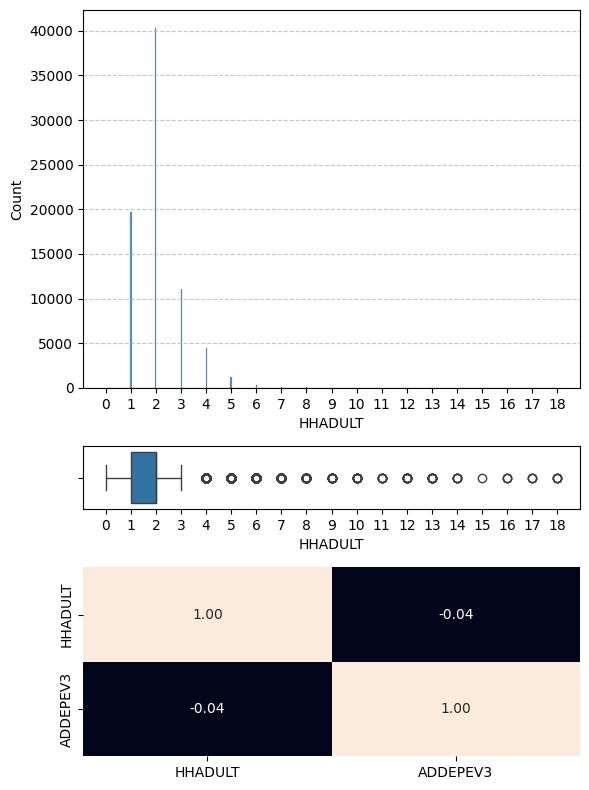

In [8]:
fig, axis = plt.subplots(3, figsize=(6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

# Histograma con ticks enteros en el eje x
sns.histplot(ax=axis[0], data=df, x="HHADULT")
axis[0].xaxis.set_major_locator(MultipleLocator(1))  # Ticks cada 1 unidad
axis[0].grid(axis='y', linestyle='--', alpha=0.7)

# Boxplot con ticks enteros en el eje x
sns.boxplot(ax=axis[1], data=df, x="HHADULT")
axis[1].xaxis.set_major_locator(MultipleLocator(1))

# Heatmap de correlación
sns.heatmap(df[["HHADULT", "ADDEPEV3"]].corr(), annot=True, fmt=".2f", ax=axis[2], cbar=False)

plt.tight_layout()
plt.show()

---

### 📊 Distribución general:
- La mayoría de los hogares tiene entre **1 y 3 adultos**, siendo el valor más común el **2**.
- A partir de 4 adultos, la frecuencia disminuye rápidamente, y los valores superiores a 6 son casos muy poco frecuentes.
- Se observan varios valores atípicos (outliers) por encima de 10 adultos, como se refleja en el boxplot.

### 🧠 Relación con `ADDEPEV3`:
- No se visualiza una diferencia clara en los niveles de depresión según el número de adultos en el hogar.
- La distribución de `ADDEPEV3` parece mantenerse similar independientemente del valor de `HHADULT`, lo que sugiere una relación débil o nula a simple vista.

### 📐 Correlación:
- **Valor de correlación**: `-0.04`  
- Se trata de una correlación negativa muy débil. Aunque estadísticamente despreciable, podría apuntar (si acaso) a una mínima tendencia a menor depresión en hogares con más adultos, posiblemente por mayor apoyo social, pero sin evidencia visual ni numérica fuerte que lo respalde.

---

## 🔎 SEXVAR – Sexo del encuestado

📂 Tipo de variable: **Categórica**

🧾 **Descripción**:  
Indica el sexo de la persona que respondió la encuesta. Esta variable es útil para identificar posibles diferencias de género en los indicadores de salud mental.

🔢 **Codificación**:  
- 0: Hombre  
- 1: Mujer

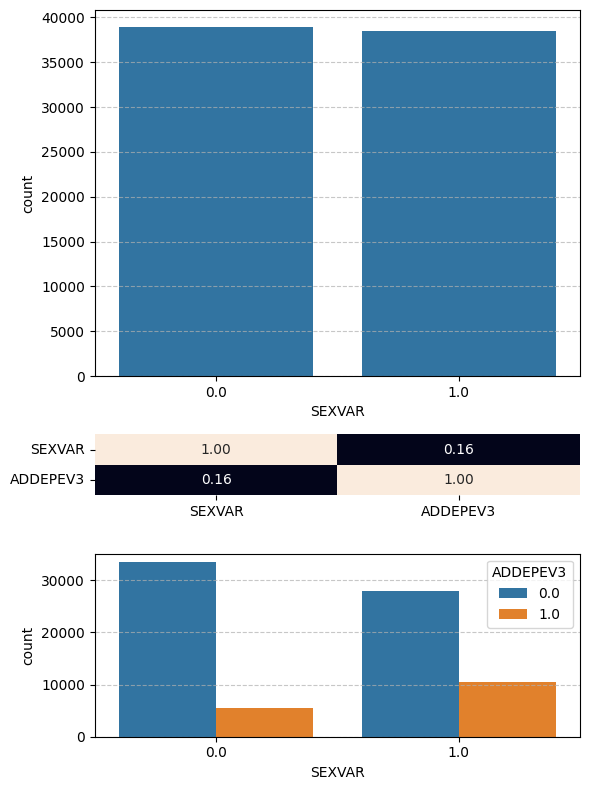

In [9]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "SEXVAR")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.heatmap(df[["SEXVAR", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "SEXVAR", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---

### 📊 Distribución general:
- La muestra está **equilibrada entre hombres y mujeres**, con cantidades casi idénticas en ambas categorías.
- Esto permite comparaciones de género sin sesgo de representación en el análisis.

### 🧠 Relación con `ADDEPEV3`:
- Se observa una **mayor proporción de depresión diagnosticada entre mujeres (1)** en comparación con los hombres (0).
- Aunque ambos sexos presentan casos de depresión, la diferencia visual es clara: las mujeres reportan un número absoluto mayor de diagnósticos.

### 📐 Correlación:
- **Valor de correlación**: `0.16`  
- La correlación es **positiva y débil**, pero mayor que en muchas otras variables. Esto sugiere una **ligera tendencia** a una mayor prevalencia de diagnóstico de depresión entre mujeres, en línea con hallazgos de salud pública previos.

---


## 🔎 MEDCOST1 – ¿Necesitó ver a un médico pero no pudo por motivos económicos?

📂 Tipo de variable: **Categórica**

🧾 **Descripción**:  
Esta variable indica si en los últimos 12 meses la persona necesitó atención médica pero no pudo acceder a ella por razones económicas. Refleja barreras en el acceso a la salud.

🔢 **Codificación**:  
- 0: No  
- 1: Sí

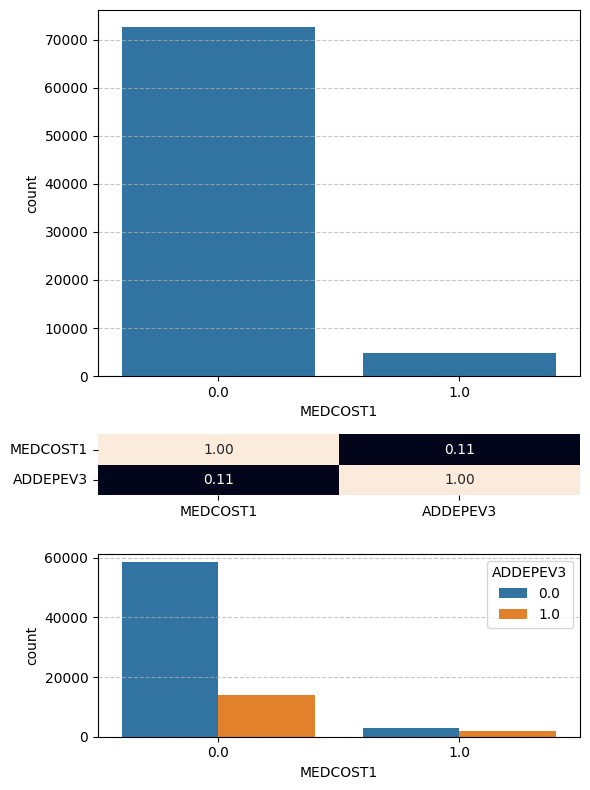

In [10]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "MEDCOST1")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.heatmap(df[["MEDCOST1", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "MEDCOST1", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---

### 📊 Distribución general:
- La gran mayoría de los encuestados indicó que **no** tuvo problemas económicos para acceder a atención médica (valor 0).
- Solo una minoría (valor 1) reportó que **sí necesitó ver a un médico pero no pudo por razones económicas**.

### 🧠 Relación con `ADDEPEV3`:
- Entre quienes **no tuvieron barreras económicas** (0), aún se reportan casos de depresión, pero en una proporción menor.
- En el grupo que **sí enfrentó barreras de costo** (1), la proporción de personas con depresión es visiblemente más alta.
- Esto sugiere una relación clara entre dificultades de acceso económico a la salud y la presencia de depresión.

### 📐 Correlación:
- **Valor de correlación**: `0.11`  
- La correlación es débil, pero positiva, y consistente con lo observado visualmente: tener problemas para acceder a atención médica parece asociarse con mayor prevalencia de depresión.

---


## 🔎 SLEPTIM1 – Horas promedio de sueño en un periodo de 24 horas

📂 Tipo de variable: **Numérica**

🧾 **Descripción**:  
Esta variable indica cuántas horas, en promedio, duerme la persona durante un día. Es un indicador clave del descanso y puede estar relacionado con la salud física y mental.

🔢 **Rango de valores**:  
- De **1 a 24** horas de sueño diarias
- Se esperan valores entre **6 y 9 horas** como lo más frecuente, según recomendaciones de salud


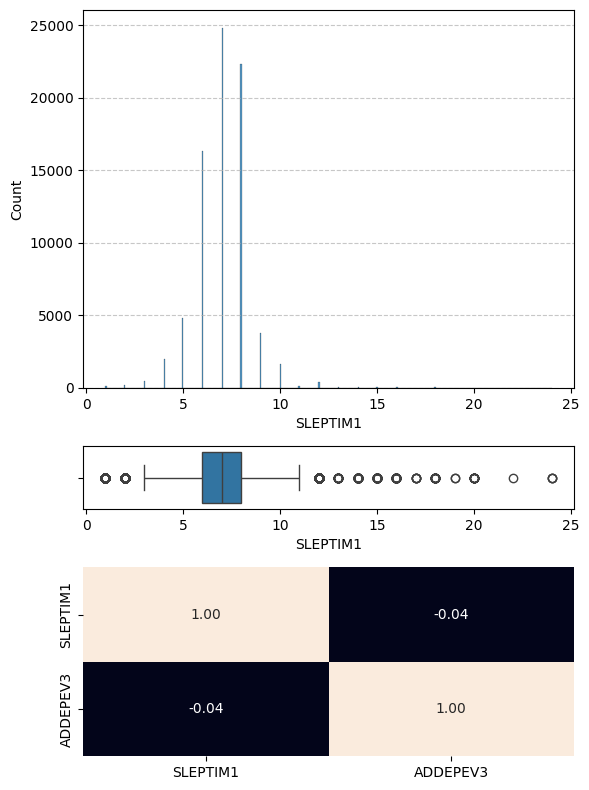

In [11]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.histplot(ax = axis[0], data = df, x = "SLEPTIM1")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)
sns.boxplot(ax = axis[1], data = df, x = "SLEPTIM1")
sns.heatmap(df[["SLEPTIM1", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[2], cbar = False)

plt.tight_layout()
plt.show()

---

### 📊 Distribución general:
- La mayoría de los encuestados duerme entre **6 y 8 horas**, siendo el **pico más frecuente las 7 horas**.
- Existen valores atípicos tanto por debajo de 4 horas como por encima de 10, incluyendo algunos casos extremos de hasta 24 horas.
- El boxplot muestra una distribución **ligeramente sesgada a la derecha**, con más outliers en valores altos.

### 🧠 Relación con `ADDEPEV3`:
- No se observa una diferencia visual clara en la distribución del sueño relacionada con la presencia o ausencia de depresión.
- Aunque es posible que existan patrones más complejos (como insomnio o hipersomnia en casos depresivos), esta gráfica no los refleja de forma evidente.

### 📐 Correlación:
- **Valor de correlación**: `-0.04`  
- La correlación es **muy débil y negativa**, lo que sugiere que dormir más horas podría estar mínimamente asociado a menor prevalencia de depresión, pero no hay evidencia contundente.

---


## 🔎 CVDSTRK3 – ¿Alguna vez le han dicho que tuvo un derrame cerebral?

📂 Tipo de variable: **Categórica**

🧾 **Descripción**:  
Esta variable indica si alguna vez un médico o profesional de la salud ha informado al encuestado que ha sufrido un accidente cerebrovascular (stroke). Es un importante indicador de antecedentes de salud neurológica.

🔢 **Codificación**:  
- 0: No  
- 1: Sí


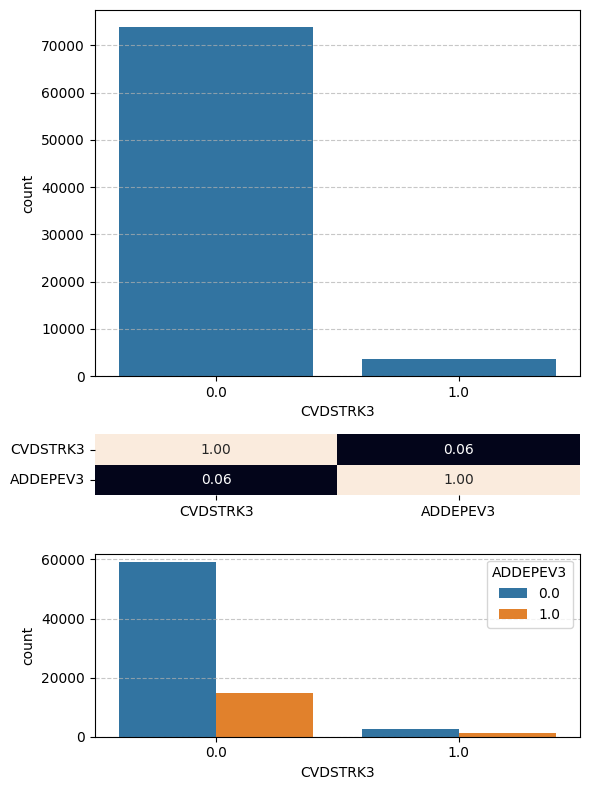

In [12]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "CVDSTRK3")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.heatmap(df[["CVDSTRK3", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "CVDSTRK3", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---

### 📊 Distribución general:
- La mayoría de los encuestados reportó **no haber sufrido un accidente cerebrovascular** (valor 0).
- Solo una pequeña proporción indicó haber tenido un derrame cerebral (valor 1), lo cual es esperable dada la prevalencia poblacional.

### 🧠 Relación con `ADDEPEV3`:
- En ambos grupos (`CVDSTRK3` = 0 y 1) se observan casos de depresión, pero la proporción de personas con diagnóstico de depresión es **visiblemente mayor** entre quienes han tenido un derrame cerebral.
- Esto sugiere una posible relación entre eventos cerebrovasculares previos y mayor vulnerabilidad a trastornos de salud mental.

### 📐 Correlación:
- **Valor de correlación**: `0.06`  
- Aunque débil, la correlación positiva es coherente con lo observado visualmente: haber sufrido un derrame cerebral se asocia con mayor frecuencia de depresión, probablemente por efectos secundarios neurológicos o emocionales del evento.

---


## 🎯 ADDEPEV3 – Diagnóstico de trastorno depresivo

📂 Tipo de variable: **Categórica (objetivo)**

🧾 **Descripción**:  
Indica si el encuestado ha sido diagnosticado alguna vez con un trastorno depresivo, incluyendo depresión mayor, distimia o depresión menor, según evaluación de un profesional de la salud.

🔢 **Codificación**:  
- 0: No  
- 1: Sí


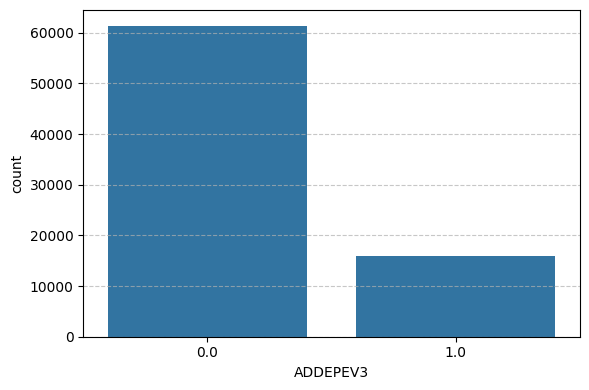

In [13]:
fig, axis = plt.subplots(figsize = (6, 4))

sns.countplot(data = df, x = "ADDEPEV3")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---

### 📊 Distribución general:
- Aproximadamente **el 20-25%** de los encuestados reporta haber sido diagnosticado con algún tipo de trastorno depresivo (valor 1).
- La mayoría (alrededor del **75-80%**) no ha recibido este diagnóstico (valor 0).
- Este desequilibrio en las clases debe tenerse en cuenta al construir modelos predictivos, ya que puede requerir técnicas de balanceo para evitar sesgo hacia la clase mayoritaria.

### 📌 Nota:
- `ADDEPEV3` es la **variable objetivo** del análisis.
- Todos los análisis de relación se realizarán respecto a esta variable para entender qué factores podrían estar asociados con mayor o menor probabilidad de depresión diagnosticada.

---


## 🔎 DIABETE4 – ¿Alguna vez le han dicho que tiene diabetes?

📂 Tipo de variable: **Categórica**

🧾 **Descripción**:  
Esta variable indica si un profesional de la salud ha diagnosticado alguna forma de diabetes al encuestado. Incluye casos confirmados, prediabetes y diabetes gestacional.

🔢 **Codificación**:  
- 0: No  
- 1: Prediabetes o intolerancia a la glucosa  
- 2: Solo durante el embarazo  
- 3: Diabetes confirmada


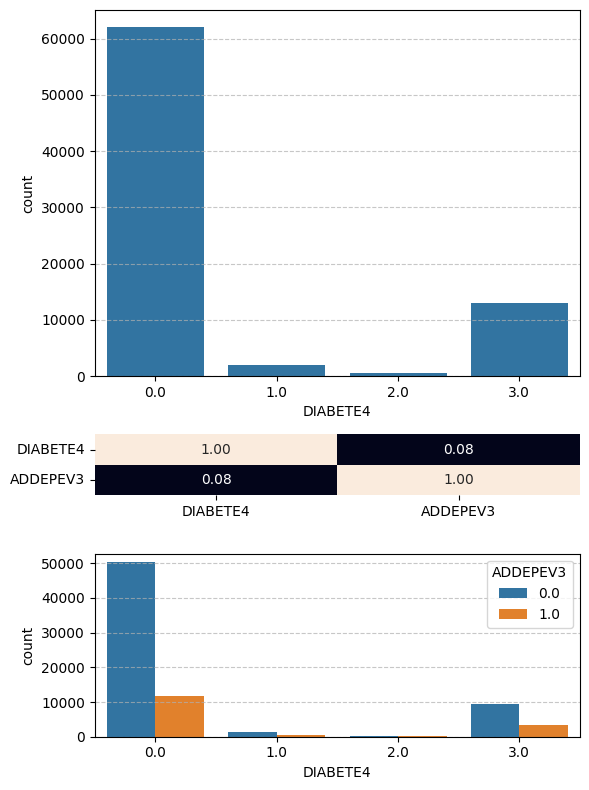

In [14]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "DIABETE4")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.heatmap(df[["DIABETE4", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "DIABETE4", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---

### 📊 Distribución general:
- La mayoría de los encuestados indicó **no tener diabetes** (valor 0).
- Un grupo considerable reporta **diabetes confirmada** (valor 3), y en menor medida aparecen casos de **prediabetes** (valor 1) y **diabetes gestacional** (valor 2).
- La clase más numerosa, con diferencia, es la de no diabéticos.

### 🧠 Relación con `ADDEPEV3`:
- En todos los subgrupos con algún tipo de diagnóstico relacionado con la diabetes (valores 1, 2 y 3), se observa una mayor proporción de personas con depresión en comparación con quienes no tienen diabetes.
- Especialmente en el grupo con **diabetes confirmada (3)**, el número absoluto de casos de depresión es claramente superior respecto a su proporción en el total de esa categoría.

### 📐 Correlación:
- **Valor de correlación**: `0.08`  
- Aunque la correlación es débil, el valor positivo respalda la observación de que **la presencia de condiciones diabéticas se asocia con una mayor prevalencia de diagnóstico de depresión**, lo cual coincide con hallazgos médicos previos sobre comorbilidades.

---


## 🔎 MARITAL – Estado civil

📂 Tipo de variable: **Categórica**

🧾 **Descripción**:  
Indica el estado civil actual del encuestado. Esta variable permite explorar posibles asociaciones entre situación conyugal y salud mental.

🔢 **Codificación**:  
- 0: Casado/a  
- 1: Divorciado/a  
- 2: Viudo/a  
- 3: Separado/a  
- 4: Nunca se ha casado  
- 5: Miembro de una pareja no casada


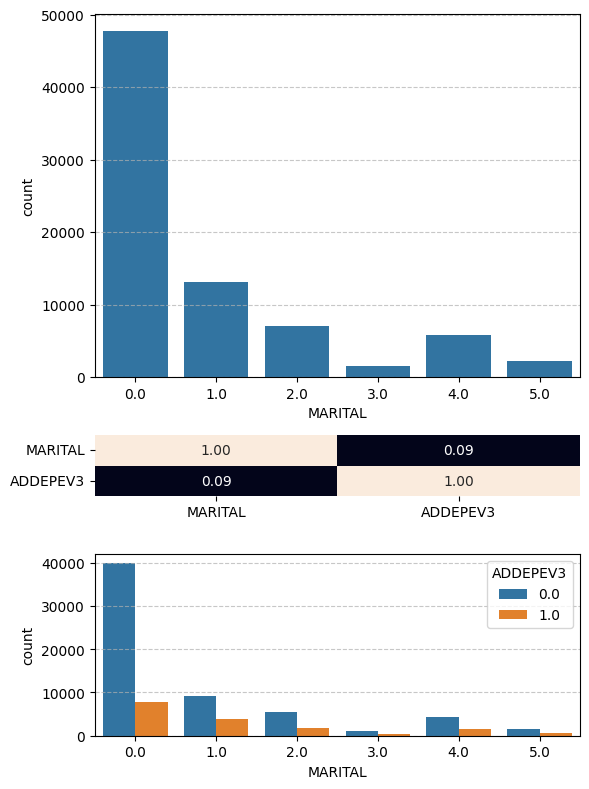

In [15]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "MARITAL")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.heatmap(df[["MARITAL", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "MARITAL", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---

### 📊 Distribución general:
- La mayoría de los encuestados se encuentra **casado/a** (valor 0), seguido por personas **divorciadas (1)** y quienes **nunca se han casado (4)**.
- Los grupos menos representados son los **separados (3)**, **viudos (2)** y quienes viven en pareja sin estar casados (5).
- Hay una diversidad notable en las situaciones conyugales reportadas.

### 🧠 Relación con `ADDEPEV3`:
- Se observa una mayor proporción de **casos de depresión** en personas **divorciadas, separadas, viudas y nunca casadas**.
- En contraste, el grupo **casado** muestra una proporción menor de diagnósticos de depresión.
- Esto sugiere una posible relación entre el estado civil y la salud mental, donde el matrimonio podría estar actuando como factor protector (o reflejo de mayor estabilidad emocional/social).

### 📐 Correlación:
- **Valor de correlación**: `0.09`  
- Aunque la correlación es débil, apunta a una posible asociación entre ciertas situaciones conyugales (especialmente separación o pérdida) y una mayor prevalencia de depresión.

---


## 🔎 RENTHOM1 – ¿Es propietario o alquila su vivienda?

📂 Tipo de variable: **Categórica**

🧾 **Descripción**:  
Indica la situación habitacional del encuestado, diferenciando entre propiedad, alquiler u otros arreglos. Esta variable puede reflejar estabilidad económica y contexto social.

🔢 **Codificación**:  
- 0: Propietario/a  
- 1: Inquilino/a (alquiler)  
- 2: Otro tipo de arreglo (vivienda prestada, compartida, etc.)


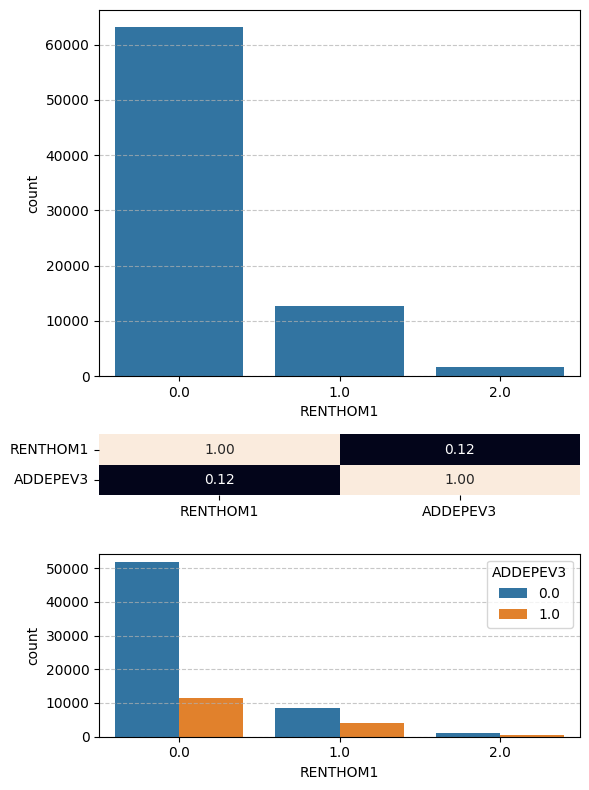

In [17]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "RENTHOM1")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.heatmap(df[["RENTHOM1", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "RENTHOM1", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---

### 📊 Distribución general:
- La mayoría de los encuestados reporta ser **propietario/a de su vivienda** (valor 0).
- Un grupo considerable vive en régimen de **alquiler** (valor 1).
- Una minoría reporta vivir bajo **otros arreglos habitacionales** (valor 2), como viviendas prestadas, familiares o compartidas.

### 🧠 Relación con `ADDEPEV3`:
- La proporción de depresión es **más alta entre quienes alquilan o viven bajo otros arreglos** que entre los propietarios.
- Esto sugiere una posible asociación entre inseguridad habitacional o menor estabilidad económica y mayor prevalencia de trastornos depresivos.

### 📐 Correlación:
- **Valor de correlación**: `0.12`  
- Es una **correlación débil pero positiva**, que respalda visualmente la tendencia observada: la falta de propiedad habitacional podría estar asociada a un mayor riesgo de depresión.

---


## 🔎 VETERAN3 – ¿Ha servido alguna vez en las Fuerzas Armadas de EE. UU.?

📂 Tipo de variable: **Categórica**

🧾 **Descripción**:  
Indica si el encuestado ha servido en servicio activo en las Fuerzas Armadas de los Estados Unidos, incluyendo servicio regular, Guardia Nacional o reservas. Esta variable puede reflejar experiencias vitales intensas con potencial impacto en la salud mental.

🔢 **Codificación**:  
- 0: No  
- 1: Sí


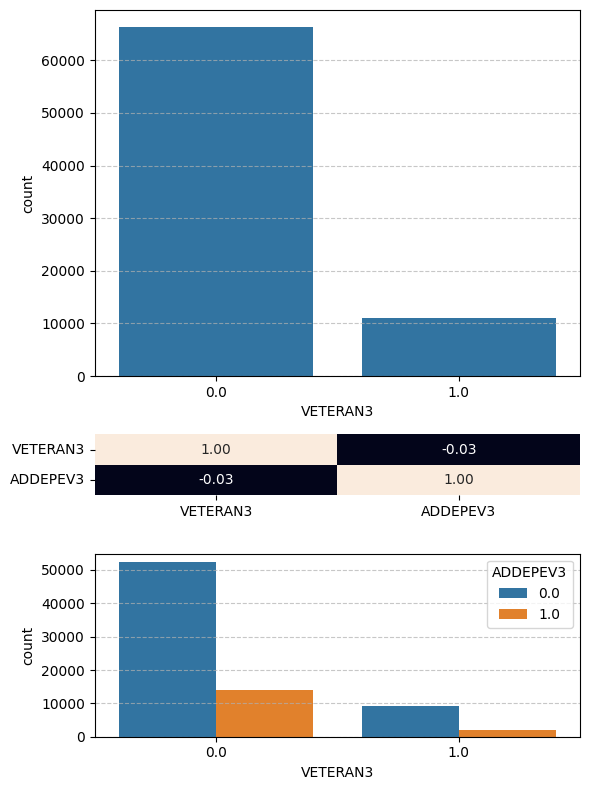

In [18]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "VETERAN3")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.heatmap(df[["VETERAN3", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "VETERAN3", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---

### 📊 Distribución general:
- La mayoría de los encuestados **no ha servido en las Fuerzas Armadas** (valor 0).
- Una minoría significativa indica que **sí ha servido en servicio activo** (valor 1).

### 🧠 Relación con `ADDEPEV3`:
- En ambos grupos (veteranos y no veteranos) hay casos de depresión, pero **no se observa una diferencia marcada** en proporciones.
- Visualmente, el grupo de veteranos muestra **una proporción algo menor de depresión** que el grupo de no veteranos, aunque esto podría estar influido por otros factores demográficos.

### 📐 Correlación:
- **Valor de correlación**: `-0.03`  
- Correlación **negativa muy débil**, sin evidencia concluyente de una relación directa entre la experiencia militar y la prevalencia de depresión en esta muestra.

---


## 🔎 EMPLOY1 – Estado laboral actual

📂 Tipo de variable: **Categórica**

🧾 **Descripción**:  
Indica la situación laboral actual del encuestado, diferenciando entre trabajo remunerado, autoempleo, desempleo, retiro y otras situaciones. Esta variable es clave para analizar el contexto socioeconómico y su posible impacto en la salud mental.

🔢 **Codificación**:  
- 0: Empleado/a con salario  
- 1: Autónomo/a  
- 2: Desempleado/a desde hace un año o más  
- 3: Desempleado/a desde hace menos de un año  
- 4: Labores del hogar  
- 5: Estudiante  
- 6: Jubilado/a  
- 7: No puede trabajar


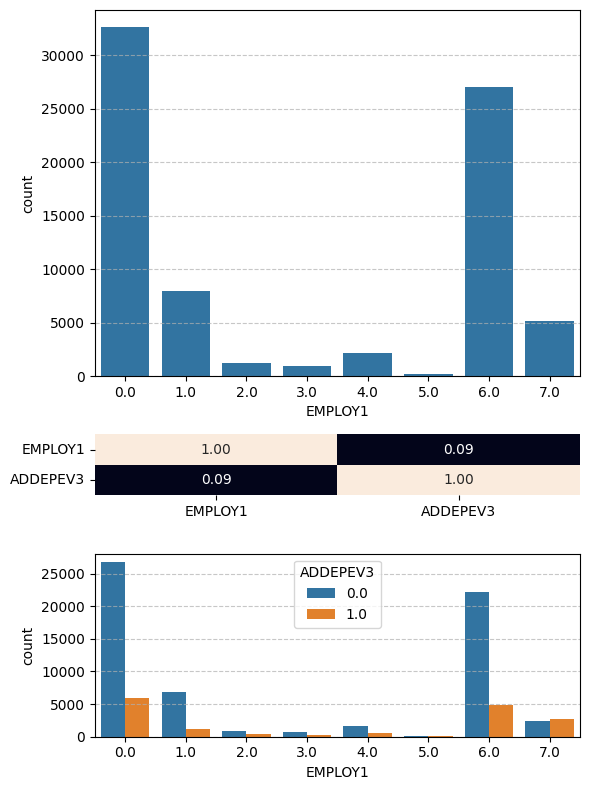

In [19]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "EMPLOY1")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.heatmap(df[["EMPLOY1", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "EMPLOY1", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---

### 📊 Distribución general:
- Las categorías más frecuentes son **empleados por salario (0)** y **jubilados (6)**.
- También hay una presencia significativa de **trabajadores autónomos (1)** y personas **que no pueden trabajar (7)**.
- Grupos como **desempleados** (2 y 3), **estudiantes** (5) y **amas de casa** (4) son menos numerosos.

### 🧠 Relación con `ADDEPEV3`:
- Las personas **que no pueden trabajar (7)** y **desempleadas** (especialmente desde hace más de un año, valor 2) presentan **una proporción elevada de diagnósticos de depresión**.
- En contraste, los **empleados con salario (0)** y **jubilados (6)** muestran proporciones más bajas.
- Esto sugiere una relación clara entre exclusión del mercado laboral y mayor prevalencia de trastornos depresivos.

### 📐 Correlación:
- **Valor de correlación**: `0.09`  
- Aunque débil, la correlación es positiva y consistente con el análisis visual: ciertas situaciones laborales, en especial la inactividad involuntaria, parecen asociarse con mayor riesgo de depresión.

---


## 🔎 DECIDE – ¿Tiene dificultades serias para concentrarse, recordar o tomar decisiones?

📂 Tipo de variable: **Categórica**

🧾 **Descripción**:  
Indica si el encuestado tiene, debido a una condición física, mental o emocional, serias dificultades para concentrarse, recordar o tomar decisiones. Esta variable puede reflejar afectaciones cognitivas relacionadas directa o indirectamente con la salud mental.

🔢 **Codificación**:  
- 0: No  
- 1: Sí


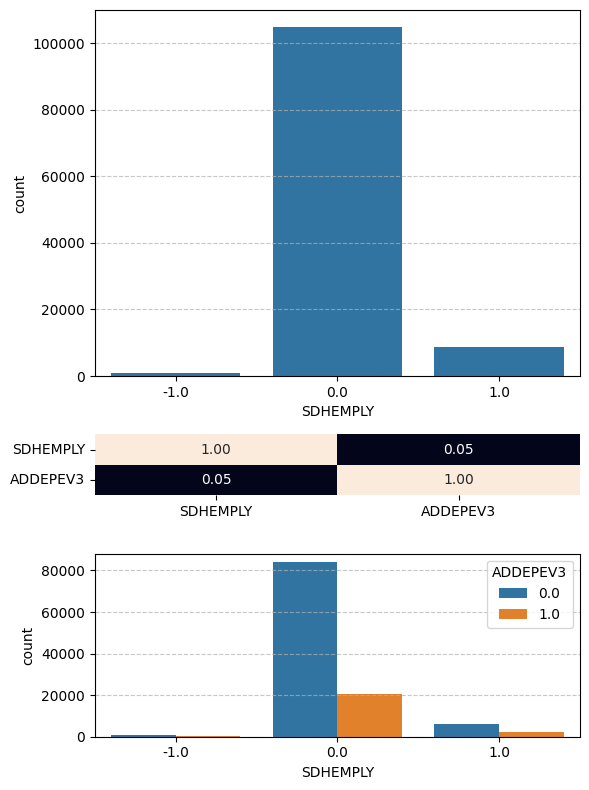

In [ ]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "SDHEMPLY")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.heatmap(df[["SDHEMPLY", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "SDHEMPLY", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

📌 SDHEMPLY – ¿Ha estado sin trabajo en los últimos 12 meses?
Codificación personalizada:

- 1: Sí
- 0: No
- -1: No contesta (sin nulos tras limpieza)

🧾 Descripción:
- Esta variable recoge si la persona ha estado desempleada durante el último año. Es un buen indicador del contexto económico y social del encuestado.

📊 Distribución general (countplot):
- La gran mayoría respondió que no ha estado sin trabajo (0).
- Una minoría declaró haber estado desempleado (1).
- Muy pocos no contestaron (-1), tras eliminar los nulos.

🧠 Relación con la salud mental (ADDEPEV3):
- Entre quienes sí estuvieron desempleados, se observa una mayor proporción de personas con diagnóstico de depresión.
- En quienes no estuvieron desempleados, la proporción es menor.
- Esta diferencia, aunque visualmente clara, no es fuerte en términos estadísticos.

📐 Correlación:
- Valor muy bajo, indica correlación débil.
- A pesar de su baja magnitud, refleja una tendencia esperable: el desempleo puede estar asociado con mayor vulnerabilidad emocional.

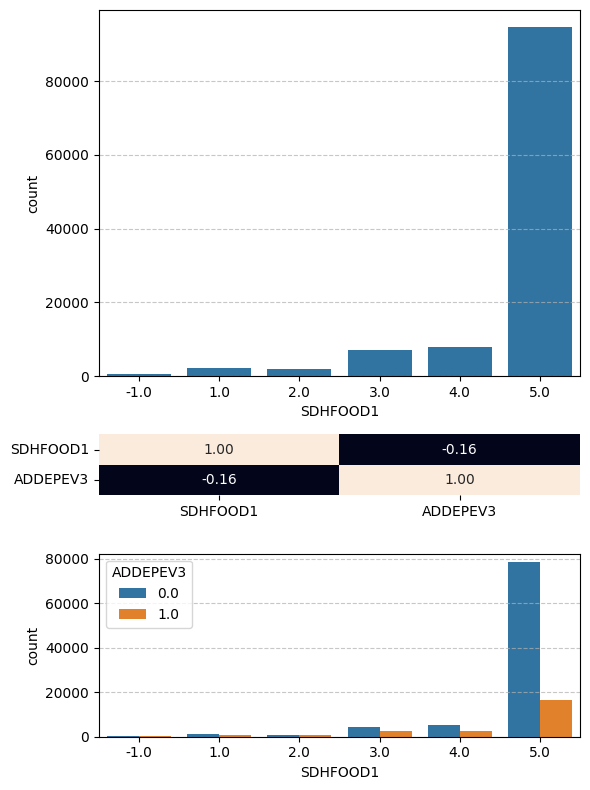

In [141]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "SDHFOOD1")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)
# sns.boxplot(ax = axis[1], data = df, x = "SDHFOOD1")
sns.heatmap(df[["SDHFOOD1", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "SDHFOOD1", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

📌 SDHFOOD1 – ¿Hubo veces en los últimos 12 meses en que no tuvo suficiente comida?
Codificación aplicada:
- 1: Siempre
- 2: Casi siempre
- 3: Algunas veces
- 4: Rara vez
- 5: Nunca
- -1: No contesta (sin nulos tras limpieza)

🧾 Descripción:
- Esta variable mide la inseguridad alimentaria del encuestado, preguntando si alguna vez en el último año se quedó sin suficiente comida por falta de dinero. Es un indicador fuerte de vulnerabilidad social y económica.

📊 Distribución general (countplot):
- La mayoría abrumadora respondió que nunca le faltó comida (5).
- Pocas personas reportaron haber pasado hambre con mayor frecuencia (1 a 4).
- Muy pocos no respondieron (-1).

🧠 Relación con la salud mental (ADDEPEV3):
- Se observa una clara tendencia: a medida que aumenta la frecuencia con la que faltó comida, también aumenta la proporción de personas con diagnóstico de depresión.
- Los valores más extremos (1 y 2) presentan una proporción visiblemente más alta de depresión respecto a quienes nunca pasaron hambre.

📐 Correlación:
- Correlación moderada. Mucho más relevante que otras variables sociales.
- Refleja una relación coherente con la evidencia: la inseguridad alimentaria tiene impacto emocional y psicológico significativo.

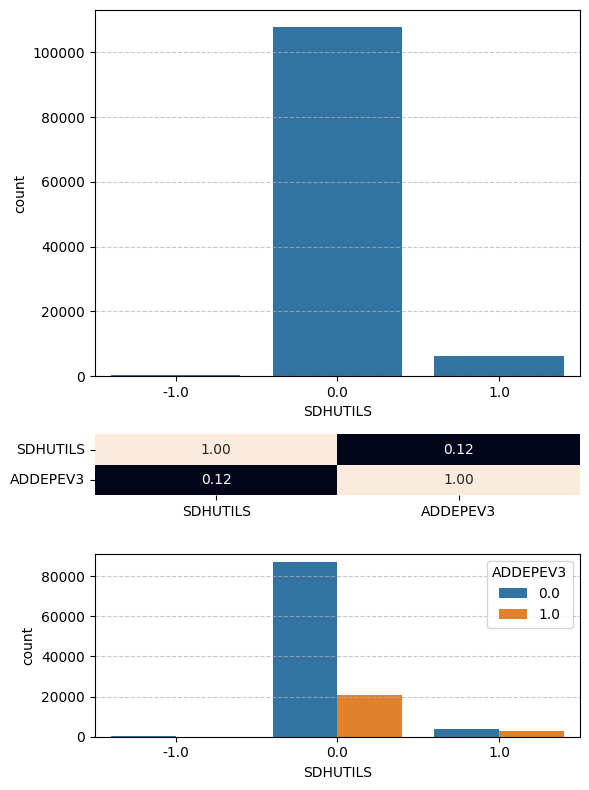

In [142]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "SDHUTILS")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)
# sns.boxplot(ax = axis[1], data = df, x = "SDHUTILS")
sns.heatmap(df[["SDHUTILS", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "SDHUTILS", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

📌 SDHUTILS – ¿Tuvo dificultades para pagar los servicios básicos (agua, luz, gas) en los últimos 12 meses?
Codificación personalizada:
- 1: Sí
- 0: No
- -1: No contesta (sin nulos tras limpieza)

🧾 Descripción:
- Esta variable refleja si el encuestado experimentó problemas económicos para pagar facturas esenciales del hogar. Es un marcador relevante de precariedad económica.

📊 Distribución general (countplot):
- La gran mayoría de los encuestados no tuvo dificultades (0).
- Un grupo menor sí reportó problemas para cubrir estos gastos (1).
- Muy pocos no respondieron (-1), tras el tratamiento previo de nulos.

🧠 Relación con la salud mental (ADDEPEV3):
- Quienes sí tuvieron problemas para pagar los servicios presentan una proporción más alta de diagnóstico de depresión.
- En cambio, en el grupo sin problemas económicos, la incidencia de depresión es claramente menor.

📐 Correlación:
- Correlación débil a moderada, pero superior al umbral típico de irrelevancia.
- Sugiere que las dificultades económicas básicas sí pueden tener impacto en la salud mental, lo cual concuerda con evidencia empírica.

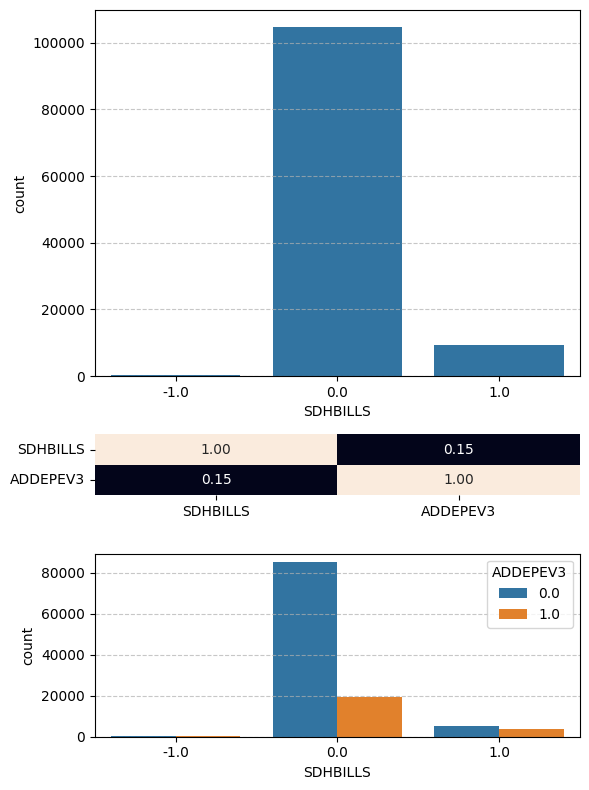

In [143]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "SDHBILLS")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)
# sns.boxplot(ax = axis[1], data = df, x = "SDHBILLS")
sns.heatmap(df[["SDHBILLS", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "SDHBILLS", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

📌 SDHBILLS – ¿Tuvo dificultades para pagar facturas importantes (hipoteca, alquiler, etc.) en los últimos 12 meses?
Codificación personalizada:
- 1: Sí
- 0: No
- -1: No contesta (sin nulos tras limpieza)

🧾 Descripción:
- Esta variable identifica si el encuestado tuvo problemas para pagar gastos estructurales importantes, como el alquiler o la hipoteca. Es un indicador clave de estrés financiero severo.

📊 Distribución general (countplot):
- La mayoría respondió que no tuvo dificultades (0).
- Un grupo menor declaró haber enfrentado problemas para pagar estas facturas (1).
- Muy pocos no contestaron (-1), tras limpieza de datos.

🧠 Relación con la salud mental (ADDEPEV3):
- Quienes sí enfrentaron problemas para pagar el alquiler o hipoteca presentan una proporción más alta de depresión.
- La diferencia con respecto al grupo sin problemas económicos es notoria visualmente, lo que sugiere una posible relación causa-efecto o al menos una asociación significativa.

📐 Correlación: 
- Correlación débil-moderada, algo superior a SDHUTILS, y cerca del umbral de relevancia práctica.
- Refuerza la idea de que los problemas financieros serios están asociados con un mayor riesgo de depresión.

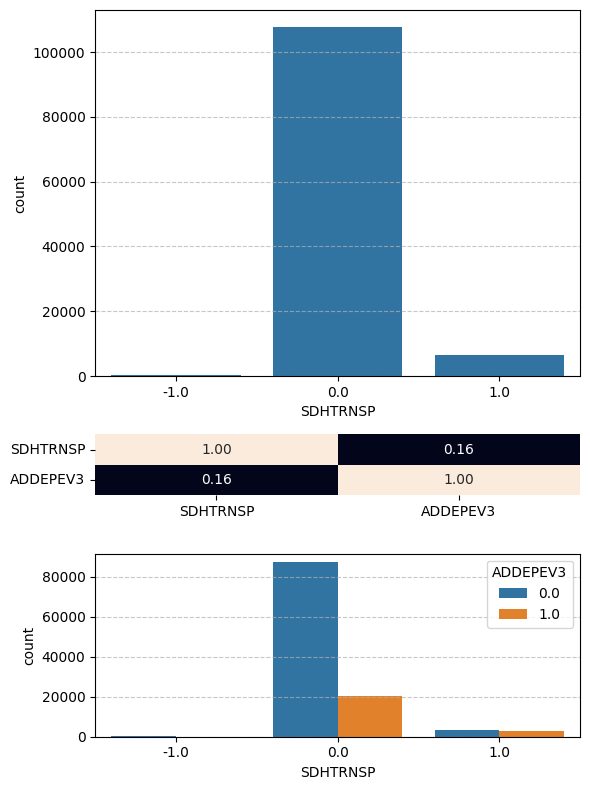

In [144]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "SDHTRNSP")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)
# sns.boxplot(ax = axis[1], data = df, x = "SDHTRNSP")
sns.heatmap(df[["SDHTRNSP", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "SDHTRNSP", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

📌 SDHTRNSP – ¿Tuvo dificultades para acceder al transporte en los últimos 12 meses?
Codificación personalizada:
- 1: Sí
- 0: No
- -1: No contesta (sin nulos tras limpieza)

🧾 Descripción:
- Esta variable indica si la persona tuvo problemas de acceso al transporte público o privado, lo que puede afectar su capacidad para trabajar, ir al médico o socializar. Es un indicador de barreras logísticas y exclusión social.

📊 Distribución general (countplot):
- La mayoría de los encuestados respondió que no tuvo dificultades (0).
- Una minoría indicó haber tenido problemas de transporte (1).
- Los que no contestaron (-1) representan un número muy reducido gracias al filtrado previo de nulos.

🧠 Relación con la salud mental (ADDEPEV3):
- Aquellos que sí tuvieron dificultades con el transporte muestran una mayor proporción de casos de depresión.
- El gráfico con la variable objetivo refuerza esta idea: hay una diferencia clara y consistente en la incidencia de depresión entre ambos grupos.

📐 Correlación: 
- Valor que indica una correlación débil-moderada, similar a la observada en otras variables relacionadas con carencias económicas o de servicios.
- Esto sugiere que la falta de acceso al transporte puede ser un factor estresante importante, con implicaciones en la salud mental.

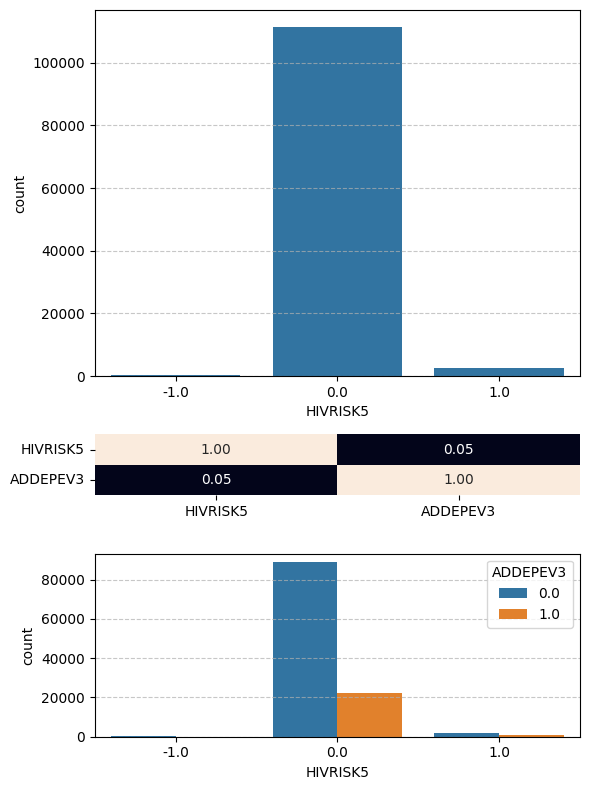

In [146]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "HIVRISK5")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)
# sns.boxplot(ax = axis[1], data = df, x = "HIVRISK5")
sns.heatmap(df[["HIVRISK5", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "HIVRISK5", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

📌 HIVRISK5 – ¿Considera que sus actividades lo ponen en riesgo de contraer VIH?
Codificación personalizada:
- 1: Sí
- 0: No
- -1: No contesta (sin nulos tras limpieza)

🧾 Descripción:
- Esta variable recoge si la persona percibe riesgo personal de contraer VIH por sus actividades. Aunque no mide conductas específicas, sí refleja una percepción de vulnerabilidad en el ámbito sexual o de salud.

📊 Distribución general (countplot):
- Una gran mayoría respondió que no se percibe en riesgo (0).
- Solo una pequeña proporción indicó que sí considera estar en riesgo (1).
- El grupo de no respuesta (-1) fue eliminado en el preprocesamiento.

🧠 Relación con la salud mental (ADDEPEV3):
- Entre quienes sí se perciben en riesgo de VIH, hay una ligeramente mayor proporción de depresión.
- El countplot desglosado por la variable objetivo muestra esta diferencia visualmente, aunque no es muy pronunciada.

📐 Correlación: 
- Correlación muy débil, apenas por encima del umbral de irrelevancia.
- Puede reflejar que las personas con conductas de riesgo o percepciones negativas sobre su salud sexual también podrían experimentar más estrés o vulnerabilidad emocional, pero no es un factor fuerte por sí solo.

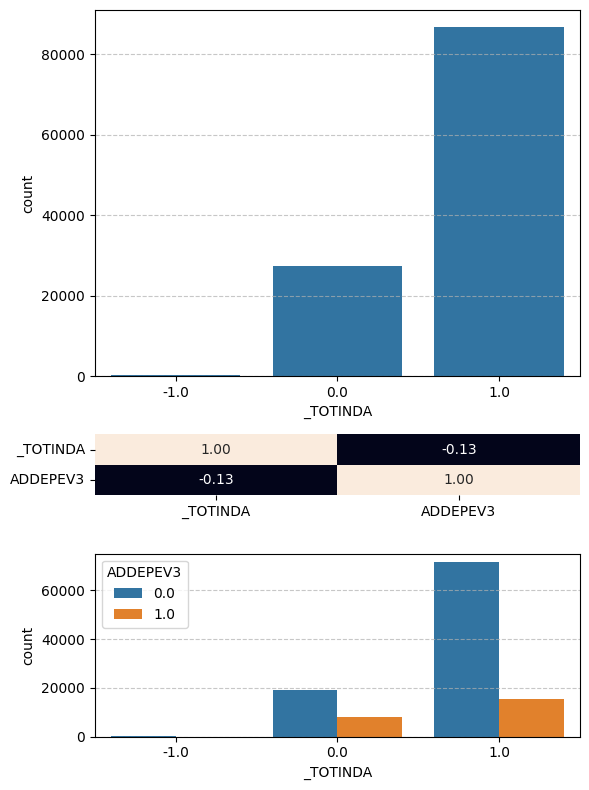

In [147]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "_TOTINDA")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)
# sns.boxplot(ax = axis[1], data = df, x = "_TOTINDA")
sns.heatmap(df[["_TOTINDA", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "_TOTINDA", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

📌 _TOTINDA – ¿Realiza algún tipo de actividad física?
Codificación personalizada:
- 1: Sí (realiza al menos actividad física moderada)
- 0: No
- -1: No contesta (ya eliminado)

🧾 Descripción:
- Esta variable refleja si la persona realiza alguna actividad física en su tiempo libre, ya sea de forma leve, moderada o vigorosa. Es un indicador muy usado en estudios sobre hábitos saludables y salud mental.

📊 Distribución general (countplot):
- La mayoría de los encuestados respondió sí (1), lo que sugiere que una gran parte de la muestra está mínimamente activa.
- Un grupo menor no realiza actividad física (0), y el grupo sin respuesta (-1) ha sido eliminado.

🧠 Relación con la salud mental (ADDEPEV3):
- Entre quienes no hacen ejercicio, se observa una proporción más alta de casos de depresión.
- Por el contrario, las personas que sí se mantienen activas presentan menor prevalencia de depresión.
- Este patrón es coherente con muchos estudios que destacan la actividad física como factor protector frente a trastornos mentales.

📐 Correlación: 
- La correlación es débil a moderada, pero significativa.
- Refuerza la hipótesis de que el ejercicio regular podría tener un efecto positivo en el estado de ánimo y bienestar mental.

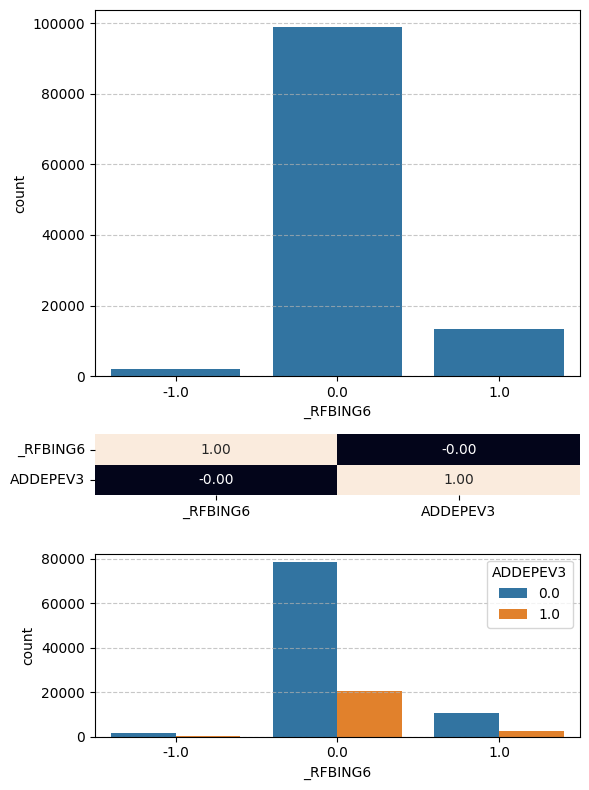

In [148]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "_RFBING6")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)
# sns.boxplot(ax = axis[1], data = df, x = "_RFBING6")
sns.heatmap(df[["_RFBING6", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "_RFBING6", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

📌 _RFBING6 – ¿Es bebedor/a compulsivo/a? (binge drinking)
Codificación personalizada:
- 1: Sí
- 0: No
- -1: No contesta (ya eliminado en la limpieza)

🧾 Descripción:
- Esta variable clasifica si el encuestado incurre en episodios de consumo excesivo de alcohol. En EE.UU., esto suele definirse como 5 o más bebidas para hombres o 4 o más para mujeres en una sola ocasión. Es un indicador de riesgo de salud y posible autodescuido.

📊 Distribución general (countplot):
- La gran mayoría de los encuestados no es bebedor compulsivo (0).
- Un grupo menor sí presenta este comportamiento (1).
- Los no respondientes (-1) fueron eliminados en el procesamiento previo.

🧠 Relación con la salud mental (ADDEPEV3):
- Visualmente, hay ligera mayor proporción de casos de depresión entre los que no presentan binge drinking que entre quienes sí.
- Esto podría parecer contraintuitivo, pero puede deberse a factores de percepción, edad o subgrupos específicos.
- En cualquier caso, la diferencia es muy pequeña.

📐 Correlación: 
- Valor extremadamente bajo, que indica ausencia práctica de correlación entre el consumo compulsivo de alcohol y el diagnóstico de depresión en este conjunto de datos.
- Aunque el alcohol se asocia con problemas de salud mental en otros estudios, en esta muestra no se refleja como un factor diferenciador claro.

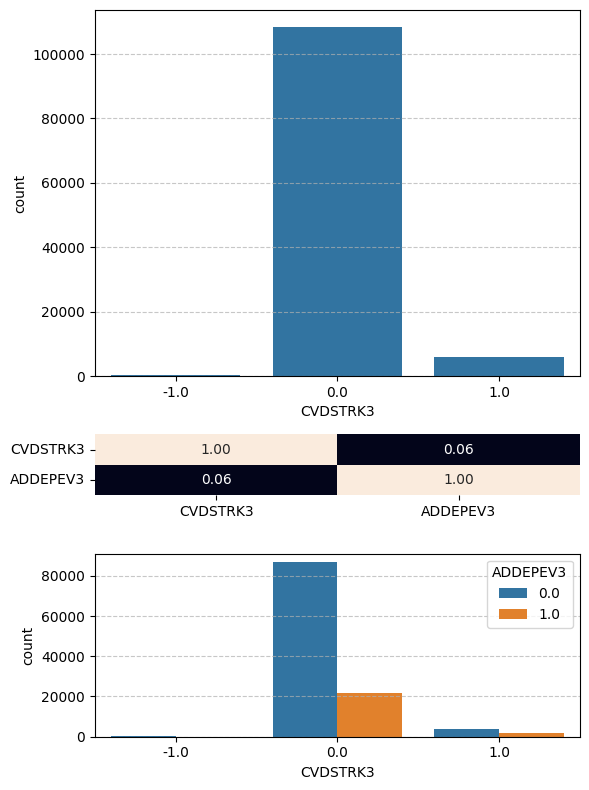

In [149]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "CVDSTRK3")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)
# sns.boxplot(ax = axis[1], data = df, x = "CVDSTRK3")
sns.heatmap(df[["CVDSTRK3", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "CVDSTRK3", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

📌 CVDSTRK3 – ¿Ha sufrido alguna vez un derrame cerebral (stroke)?
Codificación personalizada:
- 1: Sí
- 0: No
- -1: No contesta (ya eliminado del dataset)

🧾 Descripción:
- Esta variable indica si el encuestado ha sido diagnosticado alguna vez con un accidente cerebrovascular (ACV), también conocido como "stroke". Es un evento médico grave con consecuencias físicas y cognitivas que pueden impactar notablemente en la calidad de vida.

📊 Distribución general (countplot):
- La gran mayoría de los participantes no ha sufrido un ACV (0).
- Una minoría significativa sí ha tenido un derrame cerebral (1).
- Los que no respondieron (-1) ya fueron depurados.

🧠 Relación con la salud mental (ADDEPEV3):
- El gráfico revela que las personas que han sufrido un ACV presentan una mayor proporción de diagnóstico de depresión.
- Esto es esperable, dado el impacto que puede tener un ACV en la funcionalidad diaria, la independencia y el estado emocional.

📐 Correlación: 
- Correlación débil, pero ligeramente superior al umbral de irrelevancia.
- Refleja una tendencia consistente con la literatura médica, que asocia enfermedades crónicas o incapacitantes con mayor riesgo de depresión.



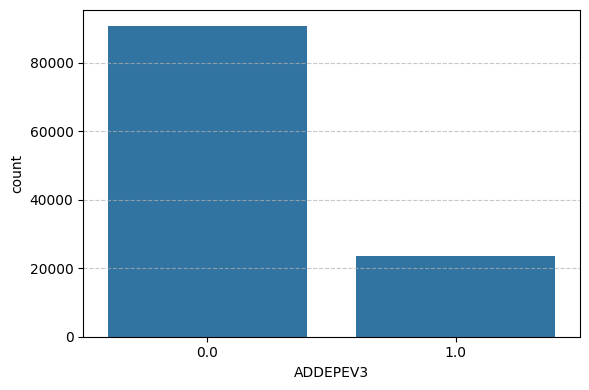

In [150]:
fig, axis = plt.subplots(figsize = (6, 4))

sns.countplot(data = df, x = "ADDEPEV3")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

🎯 ADDEPEV3 – ¿Ha sido diagnosticado con depresión alguna vez?
Codificación personalizada:
- 1: Sí
- 0: No
- -1: No contesta (ya eliminado del dataset)

🧾 Descripción:
- Esta variable representa la variable objetivo del análisis, indicando si el encuestado ha sido diagnosticado por un profesional de salud con depresión clínica en algún momento de su vida. Es un indicador directo de salud mental y permite estudiar factores asociados a este diagnóstico.

📊 Distribución general:
- La mayoría de los encuestados no ha sido diagnosticada con depresión (0): aproximadamente el 79%.
- Un 21% respondió afirmativamente (1), indicando haber recibido un diagnóstico.
- Esto nos deja con un dataset moderadamente desbalanceado, aunque aún viable para clasificación sin técnicas agresivas de balanceo.

📌 Recomendaciones:
- Considerar usar métricas como F1-score, recall y precisión para evaluar modelos, dado que el target no está perfectamente balanceado.
- Aplicar técnicas de resampling (SMOTE, undersampling, etc.) si fuese necesario al entrenar modelos.

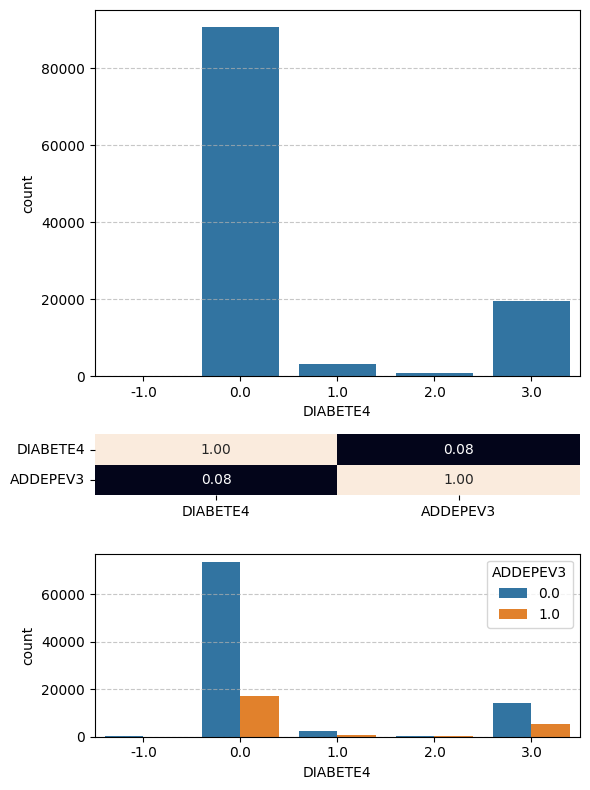

In [151]:
fig, axis = plt.subplots(3, figsize = (6, 8), gridspec_kw={"height_ratios": [6, 1, 3]})

sns.countplot(ax = axis[0], data = df, x = "DIABETE4")
axis[0].grid(axis='y', linestyle='--', alpha=0.7)
# sns.boxplot(ax = axis[1], data = df, x = "DIABETE4")
sns.heatmap(df[["DIABETE4", "ADDEPEV3"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)
sns.countplot(ax = axis[2], data = df, x = "DIABETE4", hue = "ADDEPEV3")
axis[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

📌 DIABETE4 – ¿Ha sido diagnosticado con diabetes?
Codificación original utilizada (tras limpieza de nulos):
- 1: Sí
- 2: Sí, pero solo durante el embarazo
- 3: No
- 4: No, pero en el pasado me dijeron que tenía prediabetes o "borderline"
- -1: No contesta (ya eliminado)

🧾 Descripción:
- Esta variable recoge si la persona ha sido diagnosticada con diabetes o prediabetes. Es un indicador clave de salud crónica, que podría relacionarse indirectamente con el bienestar psicológico debido al impacto que tiene en la calidad de vida.

📊 Distribución general (countplot):
- La mayoría de encuestados no tiene diabetes (3).
- Un porcentaje menor sí ha sido diagnosticado (1).
- Otros grupos incluyen prediabetes (4) y diabetes gestacional (2), aunque estos representan una proporción mucho menor.

🧠 Relación con la salud mental (ADDEPEV3):
- El gráfico muestra que las personas diagnosticadas con diabetes (1) y prediabetes (4) tienen una mayor proporción de casos de depresión.
- Esta tendencia es esperable, ya que las enfermedades crónicas pueden aumentar el riesgo de trastornos del estado de ánimo.

📐 Correlación:
- Correlación débil, pero con suficiente consistencia como para considerarla en modelos explicativos o predictivos.
- Apoya la idea de que la presencia de condiciones crónicas como la diabetes puede contribuir al deterioro de la salud mental.

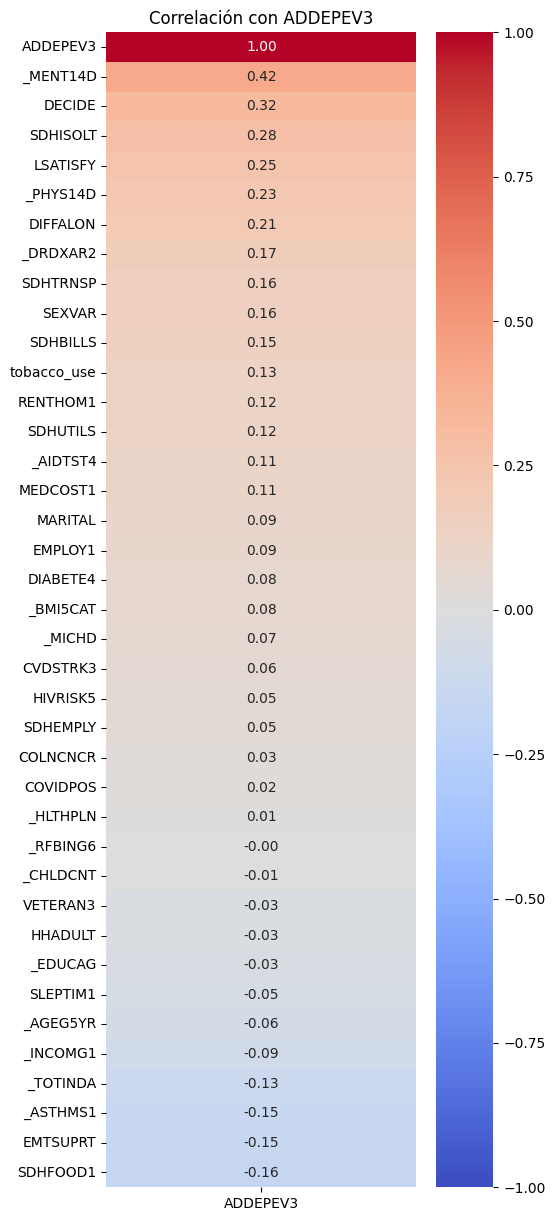

In [152]:
# Calculamos la matriz de correlación
cor_matrix = df.corr()

# Extraemos correlación con ADDEPEV3
cor_target = cor_matrix[["ADDEPEV3"]].sort_values(by="ADDEPEV3", ascending=False)

# Hacemos el heatmap
plt.figure(figsize=(5, 15))
sns.heatmap(cor_target, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlación con ADDEPEV3")
plt.show()

In [ ]:
df.to_csv("../data/processed/data_final.csv", index=False)

: 